# Adaptive merit-order forecast analysis

This notebook analyses the chronological `example_03` daily-auction feature screen for ASSUME's shadow-only adaptive merit-order correction. Existing bidding, market clearing, dispatch, and `forecaster.price` remain unchanged.

The current model is a Gaussian distributional regression: it estimates both the expected merit-order residual and its conditional standard deviation. Both equations are fitted through Gaussian Fisher scoring / IRLS and updated online with PyTorch coordinate descent, L1 feature selection, L2 coefficient stabilisation, and exponential forgetting.

In [98]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.family": "serif",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
    }
)

RESULT_DIR = Path("/tmp")
metrics = pd.read_csv(RESULT_DIR / "adaptive-irls-daily-auction-feature-screen.csv")
lag_features = "previous_day_same_hour_price"
naive_features = "naive_previous_day_same_hour_price"
screen = metrics[~metrics.features.isin([lag_features, naive_features])].copy()
benchmark = metrics[metrics.features.eq(lag_features)].iloc[0]
naive_benchmark = metrics[metrics.features.eq(naive_features)].iloc[0]
winner = screen.nsmallest(1, ["development_mae", "development_rmse"]).iloc[0]

# Evaluate merit order on exactly the same post-warm-up rows as the screen.
replay = pd.read_csv(
    RESULT_DIR / "adaptive-irls-daily-auction-winner-full-replay.csv",
    parse_dates=["product_start"],
)
trained_replay = replay[replay.training_status.eq("trained")]


def error_metrics(frame, forecast_column):
    error = frame["realised_price"] - frame[forecast_column]
    return error.abs().mean(), (error**2).mean() ** 0.5


merit_order = pd.DataFrame(
    {
        f"{period}_mae": [error_metrics(part, "merit_order_price_forecast")[0]]
        for period, part in {
            "development": trained_replay[trained_replay.product_start < "2019-10-01"],
            "holdout": trained_replay[trained_replay.product_start >= "2019-10-01"],
        }.items()
    }
).assign(
    development_rmse=error_metrics(
        trained_replay[trained_replay.product_start < "2019-10-01"],
        "merit_order_price_forecast",
    )[1],
    holdout_rmse=error_metrics(
        trained_replay[trained_replay.product_start >= "2019-10-01"],
        "merit_order_price_forecast",
    )[1],
)
merit_order.index = ["Merit-order base"]

metrics.head()

,features,feature_count,development_samples,development_mae,development_rmse,holdout_samples,holdout_mae,holdout_rmse
0,"merit_order_price, wind_availability_factor, s...",6,6024,3.752160,5.054835,2184,3.897516,5.131032
1,"merit_order_price, wind_availability_factor, s...",7,6024,3.756797,5.066653,2184,3.775759,4.976464
2,"merit_order_price, wind_availability_factor, s...",8,6024,3.794408,5.132706,2184,3.836038,5.007203
3,"merit_order_price, wind_availability_factor, s...",7,6024,3.795016,5.118379,2184,3.909580,5.081611
4,"merit_order_price, wind_availability_factor, s...",8,6024,3.796182,5.157648,2184,3.927767,5.158074


## Quick MAE/RMSE comparison

The selected model is chosen only by development-period MAE (January--September 2019), after the 504-hour warm-up. October--December 2019 remains an untouched holdout. The pre-specified previous-day-price model is an ablation benchmark, not a candidate chosen by the feature search.

,development_mae,holdout_mae,development_rmse,holdout_rmse
Merit-order base,11.982,7.128,14.415,9.915
Direct previous-day persistence,4.778,5.519,7.152,8.451
Lag-price residual model (one feature),6.130,5.574,8.169,7.439
Selected adaptive model,3.752,3.898,5.055,5.131


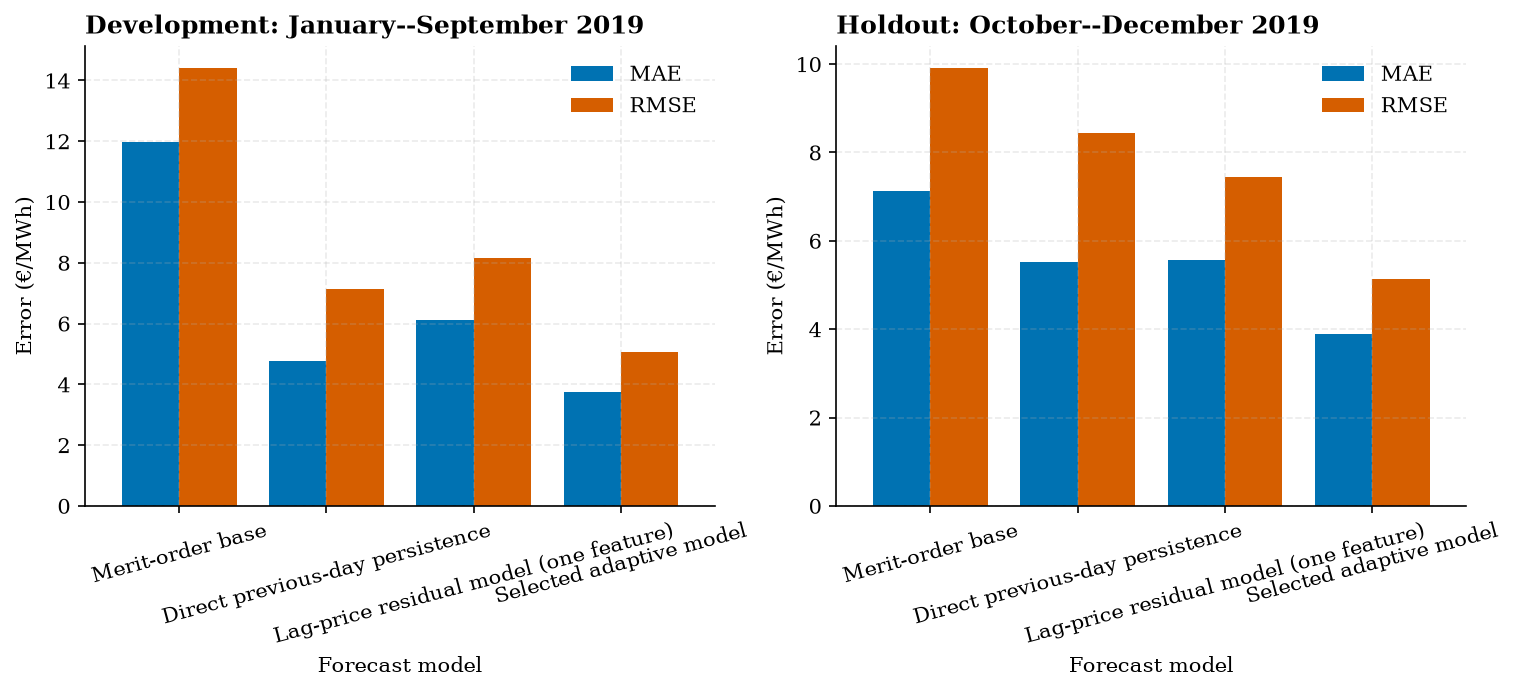

In [99]:
comparison = pd.concat(
    [
        merit_order,
        pd.DataFrame([naive_benchmark], index=["Direct previous-day persistence"])[
            ["development_mae", "development_rmse", "holdout_mae", "holdout_rmse"]
        ],
        pd.DataFrame([benchmark], index=["Lag-price residual model (one feature)"])[
            ["development_mae", "development_rmse", "holdout_mae", "holdout_rmse"]
        ],
        pd.DataFrame([winner], index=["Selected adaptive model"])[
            ["development_mae", "development_rmse", "holdout_mae", "holdout_rmse"]
        ],
    ]
)

display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for axis, period, title in zip(
    axes,
    ["development", "holdout"],
    ["Development: January--September 2019", "Holdout: October--December 2019"],
):
    comparison[[f"{period}_mae", f"{period}_rmse"]].rename(
        columns={f"{period}_mae": "MAE", f"{period}_rmse": "RMSE"}
    ).plot.bar(ax=axis, color=["#0072B2", "#D55E00"], width=0.78)
    axis.set_title(title, loc="left", fontweight="bold")
    axis.set_ylabel("Error (€/MWh)")
    axis.set_xlabel("Forecast model")
    axis.tick_params(axis="x", rotation=15)
    axis.legend(frameon=False)
plt.show()

## 1. Feature and combination design

| Feature set | Count | Features | How used |
|---|---:|---|---|
| Fixed predictors | 3 | Merit-order price; wind availability; solar availability | Included in every screened model |
| Optional predictors | 6 | Residual load; previous-day residual; previous-day price; hourly seasonality; weekday; weekend | Exhaustively combined |

The screen contains all \(2^6 = 64\) combinations of the optional predictors, each retaining the three fixed predictors. Two additional, pre-specified benchmarks are evaluated: a one-feature lag-price residual model and direct same-hour previous-day persistence. Therefore 66 cases were evaluated.

For each case, the residual mean uses an identity link and the standard deviation uses a log link. Gaussian IRLS produces the weighted working regressions, while online coordinate descent applies the L1 and L2 penalties. The default predictive distribution is Gaussian.

## 2. Chronological feature selection

Each daily auction issues and freezes all 24 hourly forecasts before any of that auction's outcomes are used. The first 504 cleared products fit and freeze feature scaling and initialise both distributional equations. Later auctions update the two equations with their cleared outcomes and forgetting factor 0.995. The development period ranks the 64 screened combinations; the holdout is reported only after that ranking.

In [100]:
top_development = screen.sort_values(["development_mae", "development_rmse"]).head(10)
top_development[
    [
        "features",
        "feature_count",
        "development_samples",
        "development_mae",
        "development_rmse",
        "holdout_mae",
        "holdout_rmse",
    ]
].round(3)

,features,feature_count,development_samples,development_mae,development_rmse,holdout_mae,holdout_rmse
0,"merit_order_price, wind_availability_factor, s...",6,6024,3.752,5.055,3.898,5.131
1,"merit_order_price, wind_availability_factor, s...",7,6024,3.757,5.067,3.776,4.976
2,"merit_order_price, wind_availability_factor, s...",8,6024,3.794,5.133,3.836,5.007
3,"merit_order_price, wind_availability_factor, s...",7,6024,3.795,5.118,3.910,5.082
4,"merit_order_price, wind_availability_factor, s...",8,6024,3.796,5.158,3.928,5.158
5,"merit_order_price, wind_availability_factor, s...",7,6024,3.798,5.139,4.039,5.280
6,"merit_order_price, wind_availability_factor, s...",6,6024,3.810,5.136,3.830,4.952
7,"merit_order_price, wind_availability_factor, s...",5,6024,3.819,5.114,4.010,5.234
8,"merit_order_price, wind_availability_factor, s...",9,6024,3.821,5.241,4.112,5.352
9,"merit_order_price, wind_availability_factor, s...",8,6024,3.830,5.211,4.146,5.364


/root/assume/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


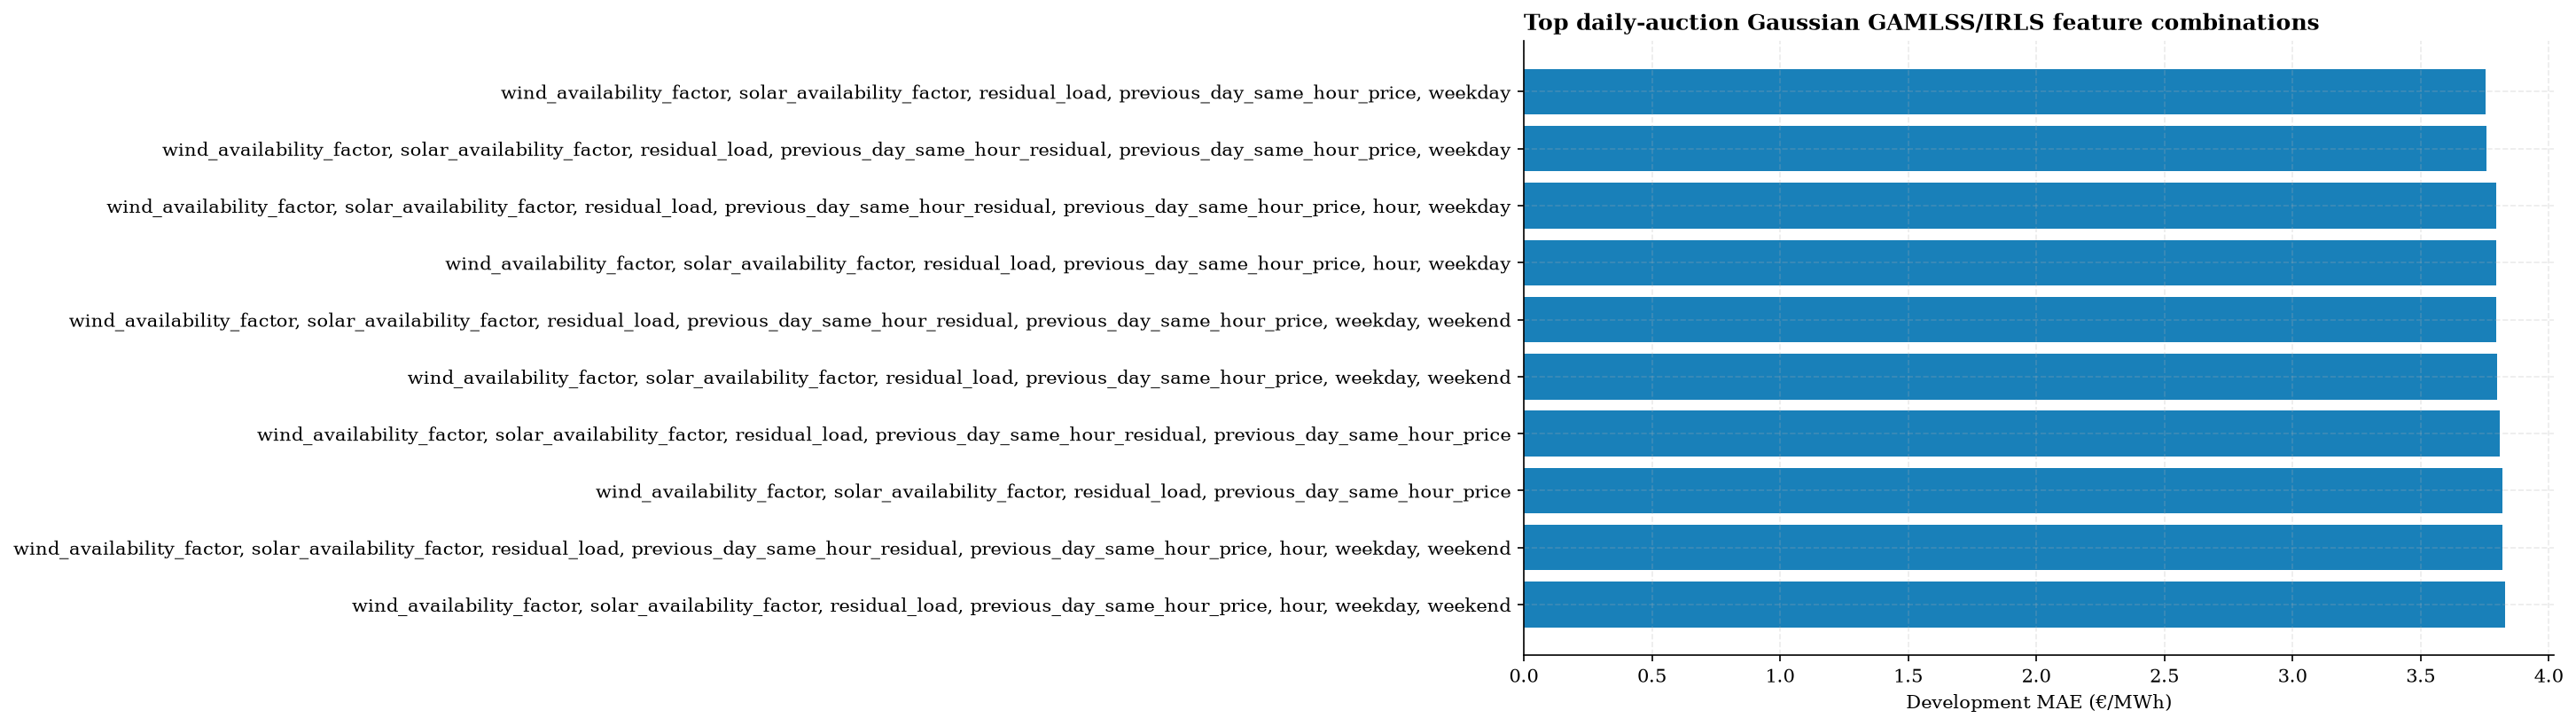

In [101]:
top = top_development.iloc[::-1].copy()
top["short_features"] = top.features.str.replace("merit_order_price, ", "", regex=False)

fig, axis = plt.subplots(figsize=(10, 6), constrained_layout=True)
axis.barh(top["short_features"], top["development_mae"], color="#0072B2", alpha=0.9)
axis.set_xlabel("Development MAE (€/MWh)")
axis.set_title(
    "Top daily-auction Gaussian GAMLSS/IRLS feature combinations",
    loc="left",
    fontweight="bold",
)
plt.show()

### Accuracy across all screened cases

The chart ranks the 64 screened combinations plus two pre-specified benchmarks by development MAE. The merit-order-only line is evaluated over exactly the same trained rows. The winner is highlighted in green; the benchmark is brown.

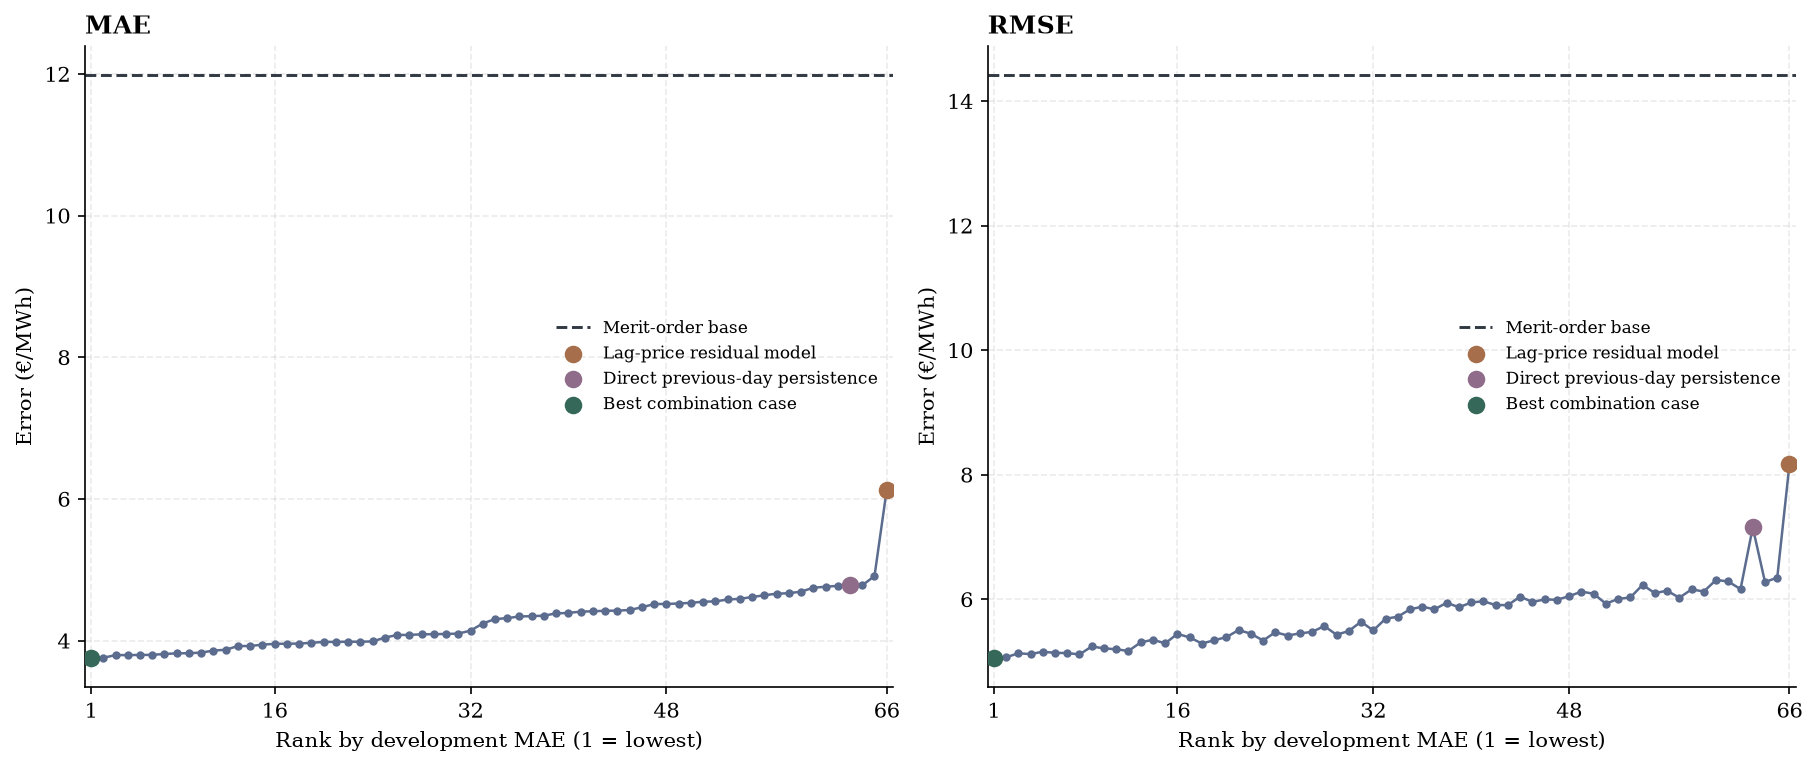

In [102]:
all_cases = (
    pd.concat(
        [
            screen.assign(case_type="Feature-screen combination"),
            pd.DataFrame([benchmark]).assign(
                case_type="Lag-price residual model (one feature)"
            ),
            pd.DataFrame([naive_benchmark]).assign(
                case_type="Direct previous-day persistence"
            ),
        ],
        ignore_index=True,
    )
    .sort_values("development_mae")
    .reset_index(drop=True)
)
all_cases["rank"] = range(1, len(all_cases) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, constrained_layout=True)
for axis, metric, title in zip(
    axes,
    ["mae", "rmse"],
    ["MAE", "RMSE"],
):
    column = f"development_{metric}"
    axis.plot(
        all_cases["rank"],
        all_cases[column],
        color="#5B6C8F",
        linewidth=1.2,
        marker="o",
        markersize=3,
    )
    axis.axhline(
        merit_order.iloc[0][column],
        color="#303841",
        linestyle="--",
        linewidth=1.4,
        label="Merit-order base",
    )
    benchmark_row = all_cases[
        all_cases.case_type.eq("Lag-price residual model (one feature)")
    ].iloc[0]
    axis.scatter(
        benchmark_row["rank"],
        benchmark_row[column],
        color="#A66E4A",
        s=55,
        zorder=3,
        label="Lag-price residual model",
    )
    naive_row = all_cases[
        all_cases.case_type.eq("Direct previous-day persistence")
    ].iloc[0]
    axis.scatter(
        naive_row["rank"],
        naive_row[column],
        color="#8E6C8A",
        s=55,
        zorder=3,
        label="Direct previous-day persistence",
    )
    axis.scatter(
        all_cases.iloc[0]["rank"],
        all_cases.iloc[0][column],
        color="#356859",
        s=55,
        zorder=3,
        label="Best combination case",
    )
    axis.set_title(title, loc="left", fontweight="bold")
    axis.set_xlabel("Rank by development MAE (1 = lowest)")
    axis.set_ylabel("Error (€/MWh)")
    axis.set_xlim(0.5, len(all_cases) + 0.5)
    axis.legend(frameon=False, fontsize=8)
axes[0].set_xticks([1, 16, 32, 48, 66])
axes[1].set_xticks([1, 16, 32, 48, 66])
plt.show()

## 3. Selected feature set

The best development-period combination contains six predictors: merit-order price, wind availability factor, solar availability factor, residual load, previous-day same-hour price, and weekday.

Its development MAE/RMSE is 3.752/5.055 €/MWh, and its holdout MAE/RMSE is 3.898/5.131 €/MWh. The one-feature lag-price residual model has holdout MAE/RMSE of 5.574/7.439 €/MWh. Direct previous-day persistence has holdout MAE/RMSE of 5.519/8.451 €/MWh. The residual model uses the previous-day same-hour price to predict the merit-order residual; persistence copies that price directly.

## 4. Forty-eight-hour price comparison

The following charts use fresh full-year detailed replays from the leakage-free daily-auction Gaussian GAMLSS/IRLS implementation. The selected model, the lag-price residual model, direct previous-day persistence, and the merit-order forecast are compared against the same realised prices. The shaded bands are central 60% intervals (q20--q80).

,Merit-order base,Lag-price residual model (one feature),Direct previous-day persistence,Selected GAMLSS/IRLS model
48-hour MAE (€/MWh),8.997,13.205,3.967,4.193


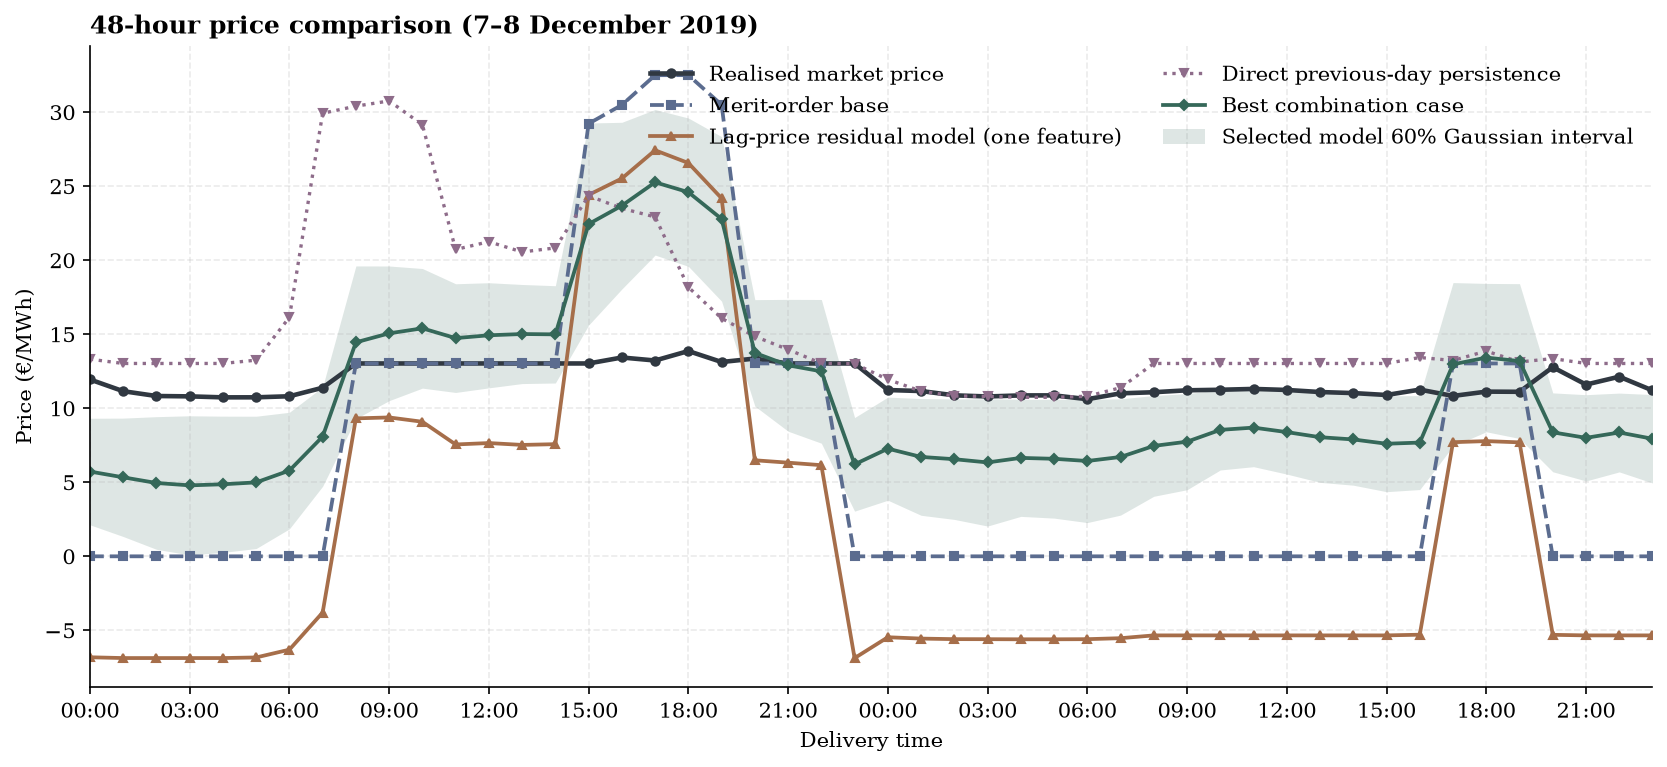

In [103]:
winner_replay = pd.read_csv(
    RESULT_DIR / "adaptive-irls-daily-auction-winner-full-replay.csv",
    parse_dates=["product_start"],
)
benchmark_replay = pd.read_csv(
    RESULT_DIR / "adaptive-irls-daily-auction-previous-day-price-full-replay.csv",
    parse_dates=["product_start"],
)
naive_replay = pd.read_csv(
    RESULT_DIR / "adaptive-irls-daily-auction-naive-previous-day-price-full-replay.csv",
    parse_dates=["product_start"],
)
window_start = pd.Timestamp("2019-12-07 00:00:00")
window_end = window_start + pd.Timedelta(hours=48)
winner_window = winner_replay[
    winner_replay.product_start.between(window_start, window_end, inclusive="left")
].set_index("product_start")
benchmark_window = benchmark_replay[
    benchmark_replay.product_start.between(window_start, window_end, inclusive="left")
].set_index("product_start")
naive_window = naive_replay[
    naive_replay.product_start.between(window_start, window_end, inclusive="left")
].set_index("product_start")
price_window = pd.DataFrame(
    {
        "Realised market price": winner_window["realised_price"],
        "Merit-order base": winner_window["merit_order_price_forecast"],
        "Lag-price residual model (one feature)": benchmark_window[
            "corrected_price_mean_forecast"
        ],
        "Direct previous-day persistence": naive_window[
            "corrected_price_mean_forecast"
        ],
        "Selected GAMLSS/IRLS model": winner_window["corrected_price_mean_forecast"],
        "Selected model q20": winner_window["price_q20"],
        "Selected model q80": winner_window["price_q80"],
    }
).sort_index()

window_errors = pd.DataFrame(
    {
        name: (price_window["Realised market price"] - price_window[name]).abs().mean()
        for name in (
            "Merit-order base",
            "Lag-price residual model (one feature)",
            "Direct previous-day persistence",
            "Selected GAMLSS/IRLS model",
        )
    },
    index=["48-hour MAE (€/MWh)"],
)
display(window_errors.round(3))

fig, axis = plt.subplots(figsize=(11, 5), constrained_layout=True)
price_window["Realised market price"].plot(
    ax=axis,
    color="#303841",
    linewidth=2.2,
    marker="o",
    markersize=4,
    label="Realised market price",
)
price_window["Merit-order base"].plot(
    ax=axis,
    color="#5B6C8F",
    linewidth=1.8,
    linestyle="--",
    marker="s",
    markersize=3.5,
    label="Merit-order base",
)
price_window["Lag-price residual model (one feature)"].plot(
    ax=axis,
    color="#A66E4A",
    linewidth=1.8,
    marker="^",
    markersize=4,
    label="Lag-price residual model (one feature)",
)
price_window["Direct previous-day persistence"].plot(
    ax=axis,
    color="#8E6C8A",
    linewidth=1.6,
    linestyle=":",
    marker="v",
    markersize=3.5,
    label="Direct previous-day persistence",
)
price_window["Selected GAMLSS/IRLS model"].plot(
    ax=axis,
    color="#356859",
    linewidth=1.8,
    marker="D",
    markersize=3.5,
    label="Best combination case",
)
axis.fill_between(
    price_window.index,
    price_window["Selected model q20"],
    price_window["Selected model q80"],
    color="#356859",
    alpha=0.16,
    linewidth=0,
    label="Selected model 60% Gaussian interval",
)
axis.set_title(
    "48-hour price comparison (7–8 December 2019)", loc="left", fontweight="bold"
)
axis.set_xlabel("Delivery time")
axis.set_ylabel("Price (€/MWh)")
axis.set_xticks(price_window.index[::3])
axis.set_xticklabels(price_window.index[::3].strftime("%H:%M"))
axis.legend(frameon=False, ncol=2)
plt.show()

### Same window with Johnson SU uncertainty

The residual-mean and residual-scale equations remain exactly the same. Only the transformation from the fitted mean and standard deviation to interval quantiles is changed from Gaussian to Johnson SU.

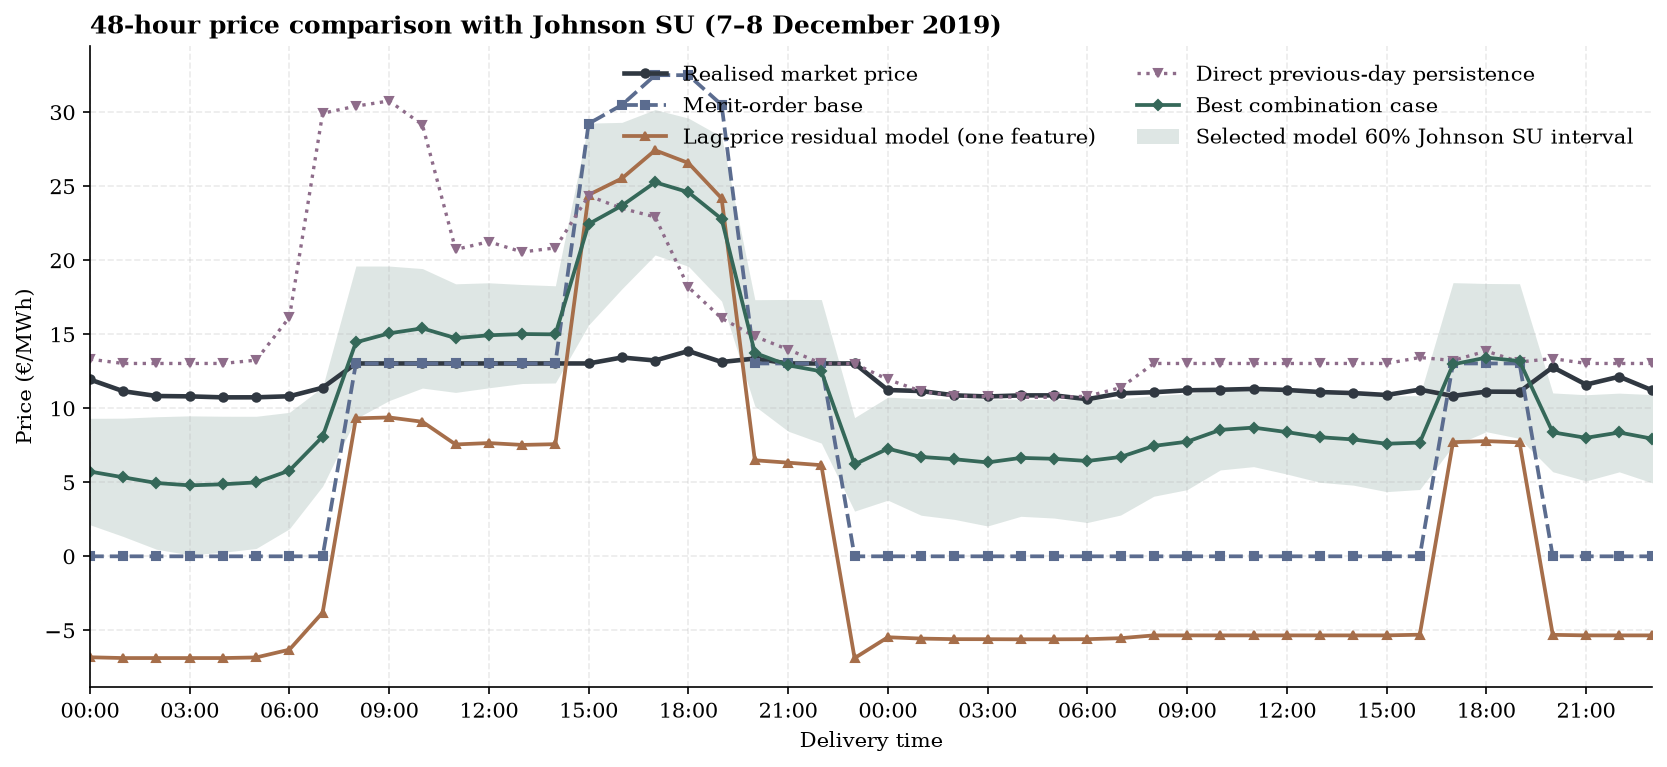

In [104]:
johnson_replay = pd.read_csv(
    RESULT_DIR / "adaptive-irls-daily-auction-johnson-su-winner-full-replay.csv",
    parse_dates=["product_start"],
)
johnson_window = johnson_replay[
    johnson_replay.product_start.between(window_start, window_end, inclusive="left")
].set_index("product_start")
johnson_price_window = pd.DataFrame(
    {
        "Realised market price": johnson_window["realised_price"],
        "Merit-order base": johnson_window["merit_order_price_forecast"],
        "Lag-price residual model (one feature)": benchmark_window[
            "corrected_price_mean_forecast"
        ],
        "Direct previous-day persistence": naive_window[
            "corrected_price_mean_forecast"
        ],
        "Selected GAMLSS/IRLS model": johnson_window["corrected_price_mean_forecast"],
        "Selected model q20": johnson_window["price_q20"],
        "Selected model q80": johnson_window["price_q80"],
    }
).sort_index()

fig, axis = plt.subplots(figsize=(11, 5), constrained_layout=True)
johnson_price_window["Realised market price"].plot(
    ax=axis,
    color="#303841",
    linewidth=2.2,
    marker="o",
    markersize=4,
    label="Realised market price",
)
johnson_price_window["Merit-order base"].plot(
    ax=axis,
    color="#5B6C8F",
    linewidth=1.8,
    linestyle="--",
    marker="s",
    markersize=3.5,
    label="Merit-order base",
)
johnson_price_window["Lag-price residual model (one feature)"].plot(
    ax=axis,
    color="#A66E4A",
    linewidth=1.8,
    marker="^",
    markersize=4,
    label="Lag-price residual model (one feature)",
)
johnson_price_window["Direct previous-day persistence"].plot(
    ax=axis,
    color="#8E6C8A",
    linewidth=1.6,
    linestyle=":",
    marker="v",
    markersize=3.5,
    label="Direct previous-day persistence",
)
price_window["Selected GAMLSS/IRLS model"].plot(
    ax=axis,
    color="#356859",
    linewidth=1.8,
    marker="D",
    markersize=3.5,
    label="Best combination case",
)
axis.fill_between(
    johnson_price_window.index,
    johnson_price_window["Selected model q20"],
    johnson_price_window["Selected model q80"],
    color="#356859",
    alpha=0.16,
    linewidth=0,
    label="Selected model 60% Johnson SU interval",
)
axis.set_title(
    "48-hour price comparison with Johnson SU (7–8 December 2019)",
    loc="left",
    fontweight="bold",
)
axis.set_xlabel("Delivery time")
axis.set_ylabel("Price (€/MWh)")
axis.set_xticks(johnson_price_window.index[::3])
axis.set_xticklabels(johnson_price_window.index[::3].strftime("%H:%M"))
axis.legend(frameon=False, ncol=2)
plt.show()

In [105]:
holdout_top = screen.sort_values(["holdout_mae", "holdout_rmse"]).head(10)
holdout_top[
    ["features", "feature_count", "holdout_samples", "holdout_mae", "holdout_rmse"]
].round(3)

,features,feature_count,holdout_samples,holdout_mae,holdout_rmse
1,"merit_order_price, wind_availability_factor, s...",7,2184,3.776,4.976
6,"merit_order_price, wind_availability_factor, s...",6,2184,3.830,4.952
2,"merit_order_price, wind_availability_factor, s...",8,2184,3.836,5.007
10,"merit_order_price, wind_availability_factor, s...",7,2184,3.885,4.951
0,"merit_order_price, wind_availability_factor, s...",6,2184,3.898,5.131
3,"merit_order_price, wind_availability_factor, s...",7,2184,3.910,5.082
4,"merit_order_price, wind_availability_factor, s...",8,2184,3.928,5.158
11,"merit_order_price, wind_availability_factor, s...",6,2184,3.987,5.112
7,"merit_order_price, wind_availability_factor, s...",5,2184,4.010,5.234
32,"merit_order_price, wind_availability_factor, s...",5,2184,4.019,5.140


## 5. Gaussian versus nonlinear-quantile uncertainty

This comparison keeps the selected six-feature merit-order correction and all realised prices identical. Only the construction of q10, q50, and q90 changes. The replay is leakage-free: each daily auction issues and freezes all 24 hourly forecasts before any outcome from that delivery day is supplied. The first 504 cleared products form the initial training window; January--September is the development period and October--December is the untouched holdout.

The interval metrics below are: empirical coverage of the central 80% interval, the percentages below q10 and above q90, mean interval width, pinball loss, and the central-80% interval score. For width, pinball loss, and interval score, lower values are better, but a narrow interval is useful only when its coverage is close to 80%.

In [106]:
import math
from collections import deque

import numpy as np

gaussian_uncertainty = pd.read_csv(
    RESULT_DIR / "adaptive-irls-daily-auction-gaussian-current-winner-full-replay.csv",
    parse_dates=["issue_time", "product_start"],
)
nonlinear_uncertainty = pd.read_csv(
    RESULT_DIR
    / "adaptive-irls-daily-auction-nonlinear-quantile-winner-full-replay.csv",
    parse_dates=["issue_time", "product_start"],
)
gaussian_uncertainty = gaussian_uncertainty[
    gaussian_uncertainty.training_status.eq("trained")
].sort_values(["issue_time", "product_start"])
nonlinear_uncertainty = nonlinear_uncertainty[
    nonlinear_uncertainty.training_status.eq("trained")
].sort_values(["issue_time", "product_start"])

alignment = gaussian_uncertainty.merge(
    nonlinear_uncertainty,
    on="product_start",
    suffixes=("_gaussian", "_nonlinear"),
    validate="one_to_one",
)
for column in (
    "realised_price",
    "merit_order_price_forecast",
    "corrected_price_mean_forecast",
):
    assert np.allclose(
        alignment[f"{column}_gaussian"], alignment[f"{column}_nonlinear"]
    )
assert (gaussian_uncertainty.issue_time < gaussian_uncertainty.product_start).all()
assert (nonlinear_uncertainty.issue_time < nonlinear_uncertainty.product_start).all()
assert gaussian_uncertainty.groupby("issue_time").size().eq(24).all()
assert nonlinear_uncertainty.groupby("issue_time").size().eq(24).all()

print(f"Aligned trained products: {len(alignment):,}")
print(f"Daily auctions: {nonlinear_uncertainty.issue_time.nunique():,}")
print("All point forecasts match and every issue time precedes delivery.")

Aligned trained products: 8,208
Daily auctions: 342
All point forecasts match and every issue time precedes delivery.


In [107]:
def pinball_loss(actual, forecast, probability):
    error = actual - forecast
    return np.maximum(probability * error, (probability - 1) * error)


def uncertainty_metrics(
    frame, lower_column="price_q10", median_column="price_q50", upper_column="price_q90"
):
    actual = frame.realised_price.to_numpy()
    lower = frame[lower_column].to_numpy()
    median = frame[median_column].to_numpy()
    upper = frame[upper_column].to_numpy()
    width = upper - lower
    interval_score = width.copy()
    interval_score += 10 * (lower - actual) * (actual < lower)
    interval_score += 10 * (actual - upper) * (actual > upper)
    point = frame.corrected_price_mean_forecast.to_numpy()
    return {
        "samples": len(frame),
        "point_MAE": np.mean(np.abs(actual - point)),
        "point_RMSE": np.sqrt(np.mean((actual - point) ** 2)),
        "q50_MAE": np.mean(np.abs(actual - median)),
        "coverage_80_%": 100 * np.mean((actual >= lower) & (actual <= upper)),
        "below_q10_%": 100 * np.mean(actual < lower),
        "above_q90_%": 100 * np.mean(actual > upper),
        "mean_width": np.mean(width),
        "interval_score": np.mean(interval_score),
        "mean_pinball": np.mean(
            np.column_stack(
                (
                    pinball_loss(actual, lower, 0.1),
                    pinball_loss(actual, median, 0.5),
                    pinball_loss(actual, upper, 0.9),
                )
            )
        ),
        "crossing_%": 100 * np.mean((lower > median) | (median > upper)),
    }


raw_rows = []
for period, condition in {
    "development": lambda frame: frame.product_start < "2019-10-01",
    "holdout": lambda frame: frame.product_start >= "2019-10-01",
}.items():
    for method, frame in {
        "Gaussian": gaussian_uncertainty,
        "Raw nonlinear quantile": nonlinear_uncertainty,
    }.items():
        raw_rows.append(
            {"period": period, "method": method}
            | uncertainty_metrics(frame[condition(frame)])
        )
raw_comparison = pd.DataFrame(raw_rows).set_index(["period", "method"])
raw_comparison.round(3)

samples  point_MAE  point_RMSE  q50_MAE  \
period      method                                                            
development Gaussian                   6024      3.752       5.055    3.752   
            Raw nonlinear quantile     6024      3.752       5.055    3.401   
holdout     Gaussian                   2184      3.898       5.131    3.898   
            Raw nonlinear quantile     2184      3.898       5.131    3.779   

                                    coverage_80_%  below_q10_%  above_q90_%  \
period      method                                                            
development Gaussian                       72.859       15.239       11.902   
            Raw nonlinear quantile         56.059       21.564       22.377   
holdout     Gaussian                       75.229       13.141       11.630   
            Raw nonlinear quantile         57.830       26.328       15.842   

                                    mean_width  interval_score  mean_pinball  \
period      method                                                             
development Gaussian                    10.524          17.434         1.207   
            Raw nonlinear quantile       6.675          18.518         1.184   
holdout     Gaussian                    11.288          17.802         1.243   
            Raw nonlinear quantile       7.631          18.974         1.262   

                                    crossing_%  
period      method                              
development Gaussian                       0.0  
            Raw nonlinear quantile         0.0  
holdout     Gaussian                       0.0  
            Raw nonlinear quantile         0.0

### Raw-interval finding

The raw nonlinear interval is not unnecessarily wide; it is substantially too narrow. On the holdout it has 57.83% coverage instead of 80%, with 26.33% of prices below q10 and 15.84% above q90. Its mean width is 7.63 EUR/MWh versus 11.29 EUR/MWh for Gaussian, but its interval score and mean pinball loss are worse. The nonlinear q50 nevertheless has a lower holdout MAE, suggesting that the nonlinear model learns useful structure even though its raw tails require calibration.

In [108]:
def calibrate_quantile_tails(frame, window_days, minimum_days=7):
    lower_history = deque(maxlen=None if window_days is None else window_days * 24)
    upper_history = deque(maxlen=None if window_days is None else window_days * 24)
    calibrated_lower = []
    calibrated_upper = []

    for _, auction in frame.groupby("issue_time", sort=True):
        if len(lower_history) >= minimum_days * 24:
            count = len(lower_history)
            probability = min(1, math.ceil((count + 1) * 0.9) / count)
            lower_adjustment = np.quantile(lower_history, probability, method="higher")
            upper_adjustment = np.quantile(upper_history, probability, method="higher")
        else:
            lower_adjustment = upper_adjustment = 0.0

        calibrated_lower.extend((auction.price_q10 - lower_adjustment).tolist())
        calibrated_upper.extend((auction.price_q90 + upper_adjustment).tolist())
        lower_history.extend((auction.price_q10 - auction.realised_price).tolist())
        upper_history.extend((auction.realised_price - auction.price_q90).tolist())

    calibrated = frame.copy()
    calibrated["calibrated_q10"] = calibrated_lower
    calibrated["calibrated_q90"] = calibrated_upper
    return calibrated


calibration_runs = {}
calibration_rows = []
for days in (7, 14, 28, 60, 90, None):
    label = "expanding" if days is None else f"{days} days"
    calibrated_run = calibrate_quantile_tails(nonlinear_uncertainty, days)
    calibration_runs[label] = calibrated_run
    development = calibrated_run[calibrated_run.product_start < "2019-10-01"]
    row = uncertainty_metrics(
        development, lower_column="calibrated_q10", upper_column="calibrated_q90"
    )
    row["tail_calibration_error"] = abs(row["below_q10_%"] - 10) + abs(
        row["above_q90_%"] - 10
    )
    calibration_rows.append({"window": label} | row)

calibration_screen = pd.DataFrame(calibration_rows).set_index("window")
selected_window = calibration_screen.sort_values(
    ["tail_calibration_error", "interval_score"]
).index[0]
calibrated_nonlinear = calibration_runs[selected_window]
print(f"Selected using development data only: {selected_window}")
calibration_screen[
    [
        "coverage_80_%",
        "below_q10_%",
        "above_q90_%",
        "mean_width",
        "interval_score",
        "tail_calibration_error",
    ]
].round(3)

Selected using development data only: 14 days


,coverage_80_%,below_q10_%,above_q90_%,mean_width,interval_score,tail_calibration_error
window,,,,,,
7 days,77.722,10.906,11.371,11.090,16.861,2.278
14 days,78.486,10.176,11.338,10.847,16.506,1.514
28 days,79.067,9.661,11.272,10.813,16.527,1.610
60 days,79.499,9.412,11.089,10.943,16.662,1.677
90 days,80.129,8.914,10.956,11.053,16.500,2.042
expanding,81.773,7.653,10.574,11.526,16.535,2.922


In [109]:
holdout_gaussian = gaussian_uncertainty[
    gaussian_uncertainty.product_start >= "2019-10-01"
]
holdout_nonlinear = nonlinear_uncertainty[
    nonlinear_uncertainty.product_start >= "2019-10-01"
]
holdout_calibrated = calibrated_nonlinear[
    calibrated_nonlinear.product_start >= "2019-10-01"
]
final_comparison = pd.DataFrame(
    {
        "Gaussian": uncertainty_metrics(holdout_gaussian),
        "Raw nonlinear quantile": uncertainty_metrics(holdout_nonlinear),
        f"Calibrated nonlinear ({selected_window})": uncertainty_metrics(
            holdout_calibrated,
            lower_column="calibrated_q10",
            upper_column="calibrated_q90",
        ),
    }
).T
display(
    final_comparison[
        [
            "samples",
            "coverage_80_%",
            "below_q10_%",
            "above_q90_%",
            "mean_width",
            "interval_score",
            "mean_pinball",
            "q50_MAE",
            "crossing_%",
        ]
    ].round(3)
)

monthly_rows = []
for method, frame, lower, upper in (
    ("Gaussian", holdout_gaussian, "price_q10", "price_q90"),
    ("Raw nonlinear", holdout_nonlinear, "price_q10", "price_q90"),
    ("Calibrated nonlinear", holdout_calibrated, "calibrated_q10", "calibrated_q90"),
):
    for month, part in frame.groupby(frame.product_start.dt.to_period("M")):
        monthly_rows.append(
            {"method": method, "month": str(month)}
            | uncertainty_metrics(part, lower_column=lower, upper_column=upper)
        )
monthly_uncertainty = pd.DataFrame(monthly_rows)
monthly_uncertainty[
    [
        "method",
        "month",
        "coverage_80_%",
        "below_q10_%",
        "above_q90_%",
        "mean_width",
        "interval_score",
    ]
].round(3)

,samples,coverage_80_%,below_q10_%,above_q90_%,mean_width,interval_score,mean_pinball,q50_MAE,crossing_%
Gaussian,2184.0,75.229,13.141,11.630,11.288,17.802,1.243,3.898,0.000
Raw nonlinear quantile,2184.0,57.830,26.328,15.842,7.631,18.974,1.262,3.779,0.000
Calibrated nonlinear (14 days),2184.0,79.121,11.493,9.386,11.436,17.282,1.206,3.779,0.412


,method,month,coverage_80_%,below_q10_%,above_q90_%,mean_width,interval_score
0,Gaussian,2019-10,76.075,3.898,20.027,13.374,19.661
1,Gaussian,2019-11,78.611,12.083,9.306,9.554,14.919
2,Gaussian,2019-12,70.972,23.750,5.278,10.867,18.763
3,Raw nonlinear,2019-10,62.634,22.043,15.323,8.827,18.489
4,Raw nonlinear,2019-11,59.583,26.111,14.306,7.502,17.251
5,Raw nonlinear,2019-12,51.111,30.972,17.917,6.525,21.199
6,Calibrated nonlinear,2019-10,81.720,13.038,5.242,13.243,17.508
7,Calibrated nonlinear,2019-11,79.167,9.583,11.250,10.193,16.061
8,Calibrated nonlinear,2019-12,76.389,11.806,11.806,10.813,18.269


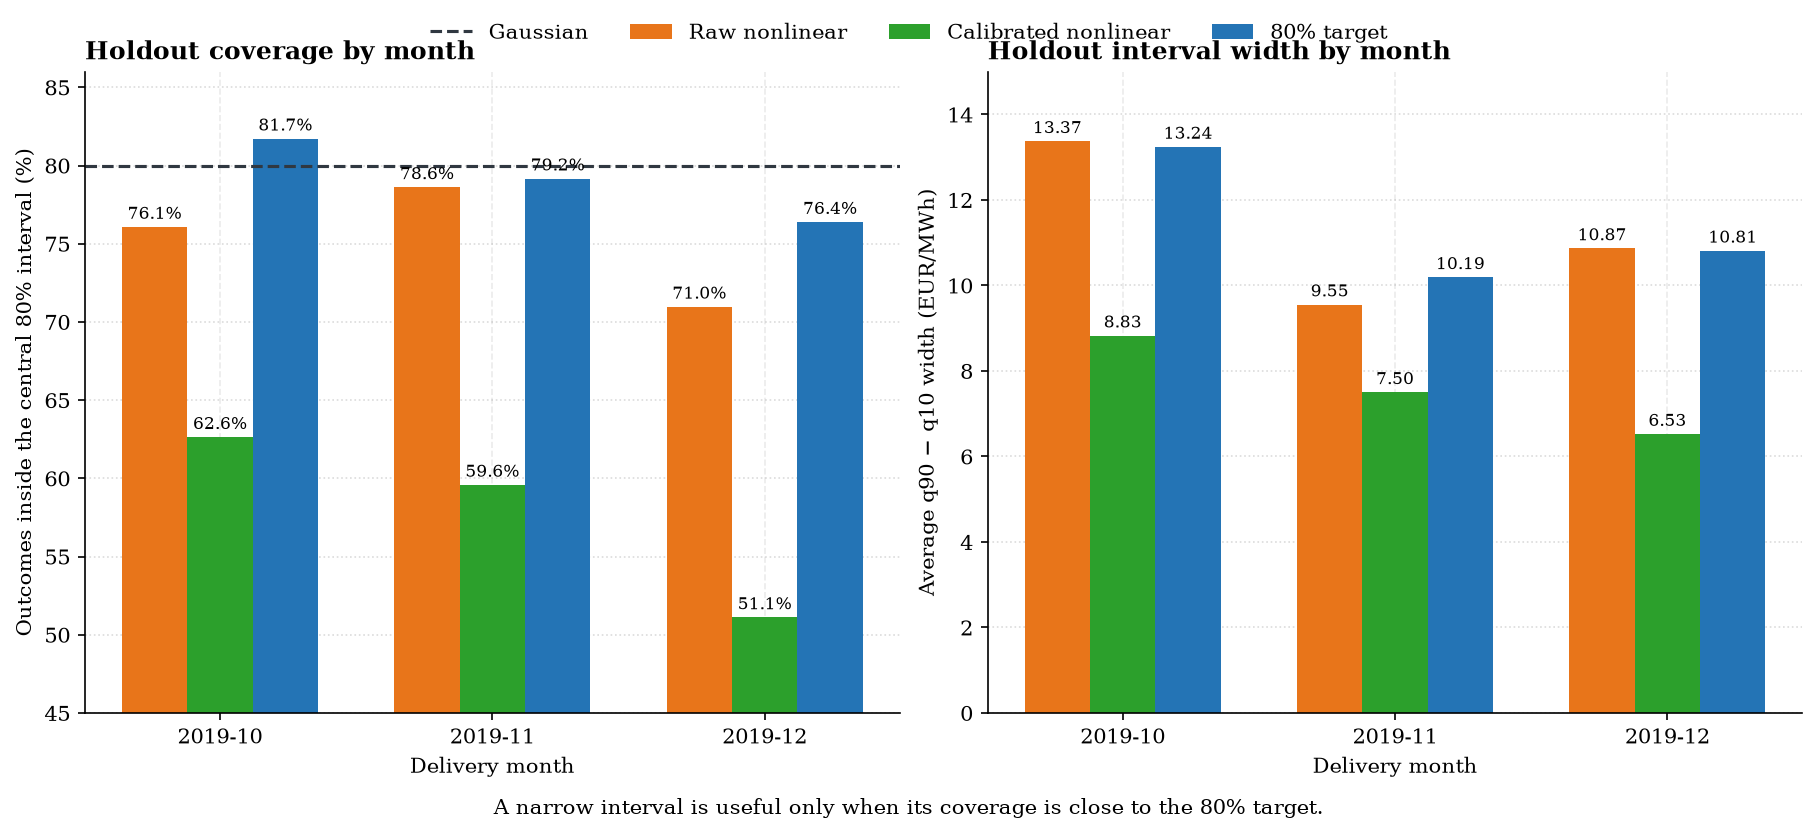

In [110]:
# Grouped bars make the month-by-month comparison easier to read than overlapping lines.
method_order = ["Gaussian", "Raw nonlinear", "Calibrated nonlinear"]
method_colors = {
    "Gaussian": "#E8751A",
    "Raw nonlinear": "#2CA02C",
    "Calibrated nonlinear": "#2474B5",
}
month_order = sorted(monthly_uncertainty["month"].unique())
coverage = monthly_uncertainty.pivot(
    index="month", columns="method", values="coverage_80_%"
).reindex(index=month_order, columns=method_order)
width = monthly_uncertainty.pivot(
    index="month", columns="method", values="mean_width"
).reindex(index=month_order, columns=method_order)
x = np.arange(len(month_order))
bar_width = 0.24
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for position, method in enumerate(method_order):
    offset = (position - 1) * bar_width
    coverage_bars = axes[0].bar(
        x + offset,
        coverage[method],
        bar_width,
        color=method_colors[method],
        label=method,
    )
    width_bars = axes[1].bar(
        x + offset,
        width[method],
        bar_width,
        color=method_colors[method],
        label=method,
    )
    axes[0].bar_label(coverage_bars, fmt="%.1f%%", padding=2, fontsize=8)
    axes[1].bar_label(width_bars, fmt="%.2f", padding=2, fontsize=8)
axes[0].axhline(80, color="#303841", linestyle="--", linewidth=1.5, label="80% target")
axes[0].set_title("Holdout coverage by month", loc="left", fontweight="bold")
axes[0].set_ylabel("Outcomes inside the central 80% interval (%)")
axes[0].set_ylim(45, 86)
axes[1].set_title("Holdout interval width by month", loc="left", fontweight="bold")
axes[1].set_ylabel("Average q90 − q10 width (EUR/MWh)")
axes[1].set_ylim(0, 15)
for axis in axes:
    axis.set_xticks(x, month_order)
    axis.set_xlabel("Delivery month")
    axis.grid(axis="y", linestyle=":", alpha=0.45)
    axis.set_axisbelow(True)
fig.legend(
    method_order + ["80% target"],
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
)
fig.text(
    0.5,
    -0.04,
    "A narrow interval is useful only when its coverage is close to the 80% target.",
    ha="center",
)
plt.show()

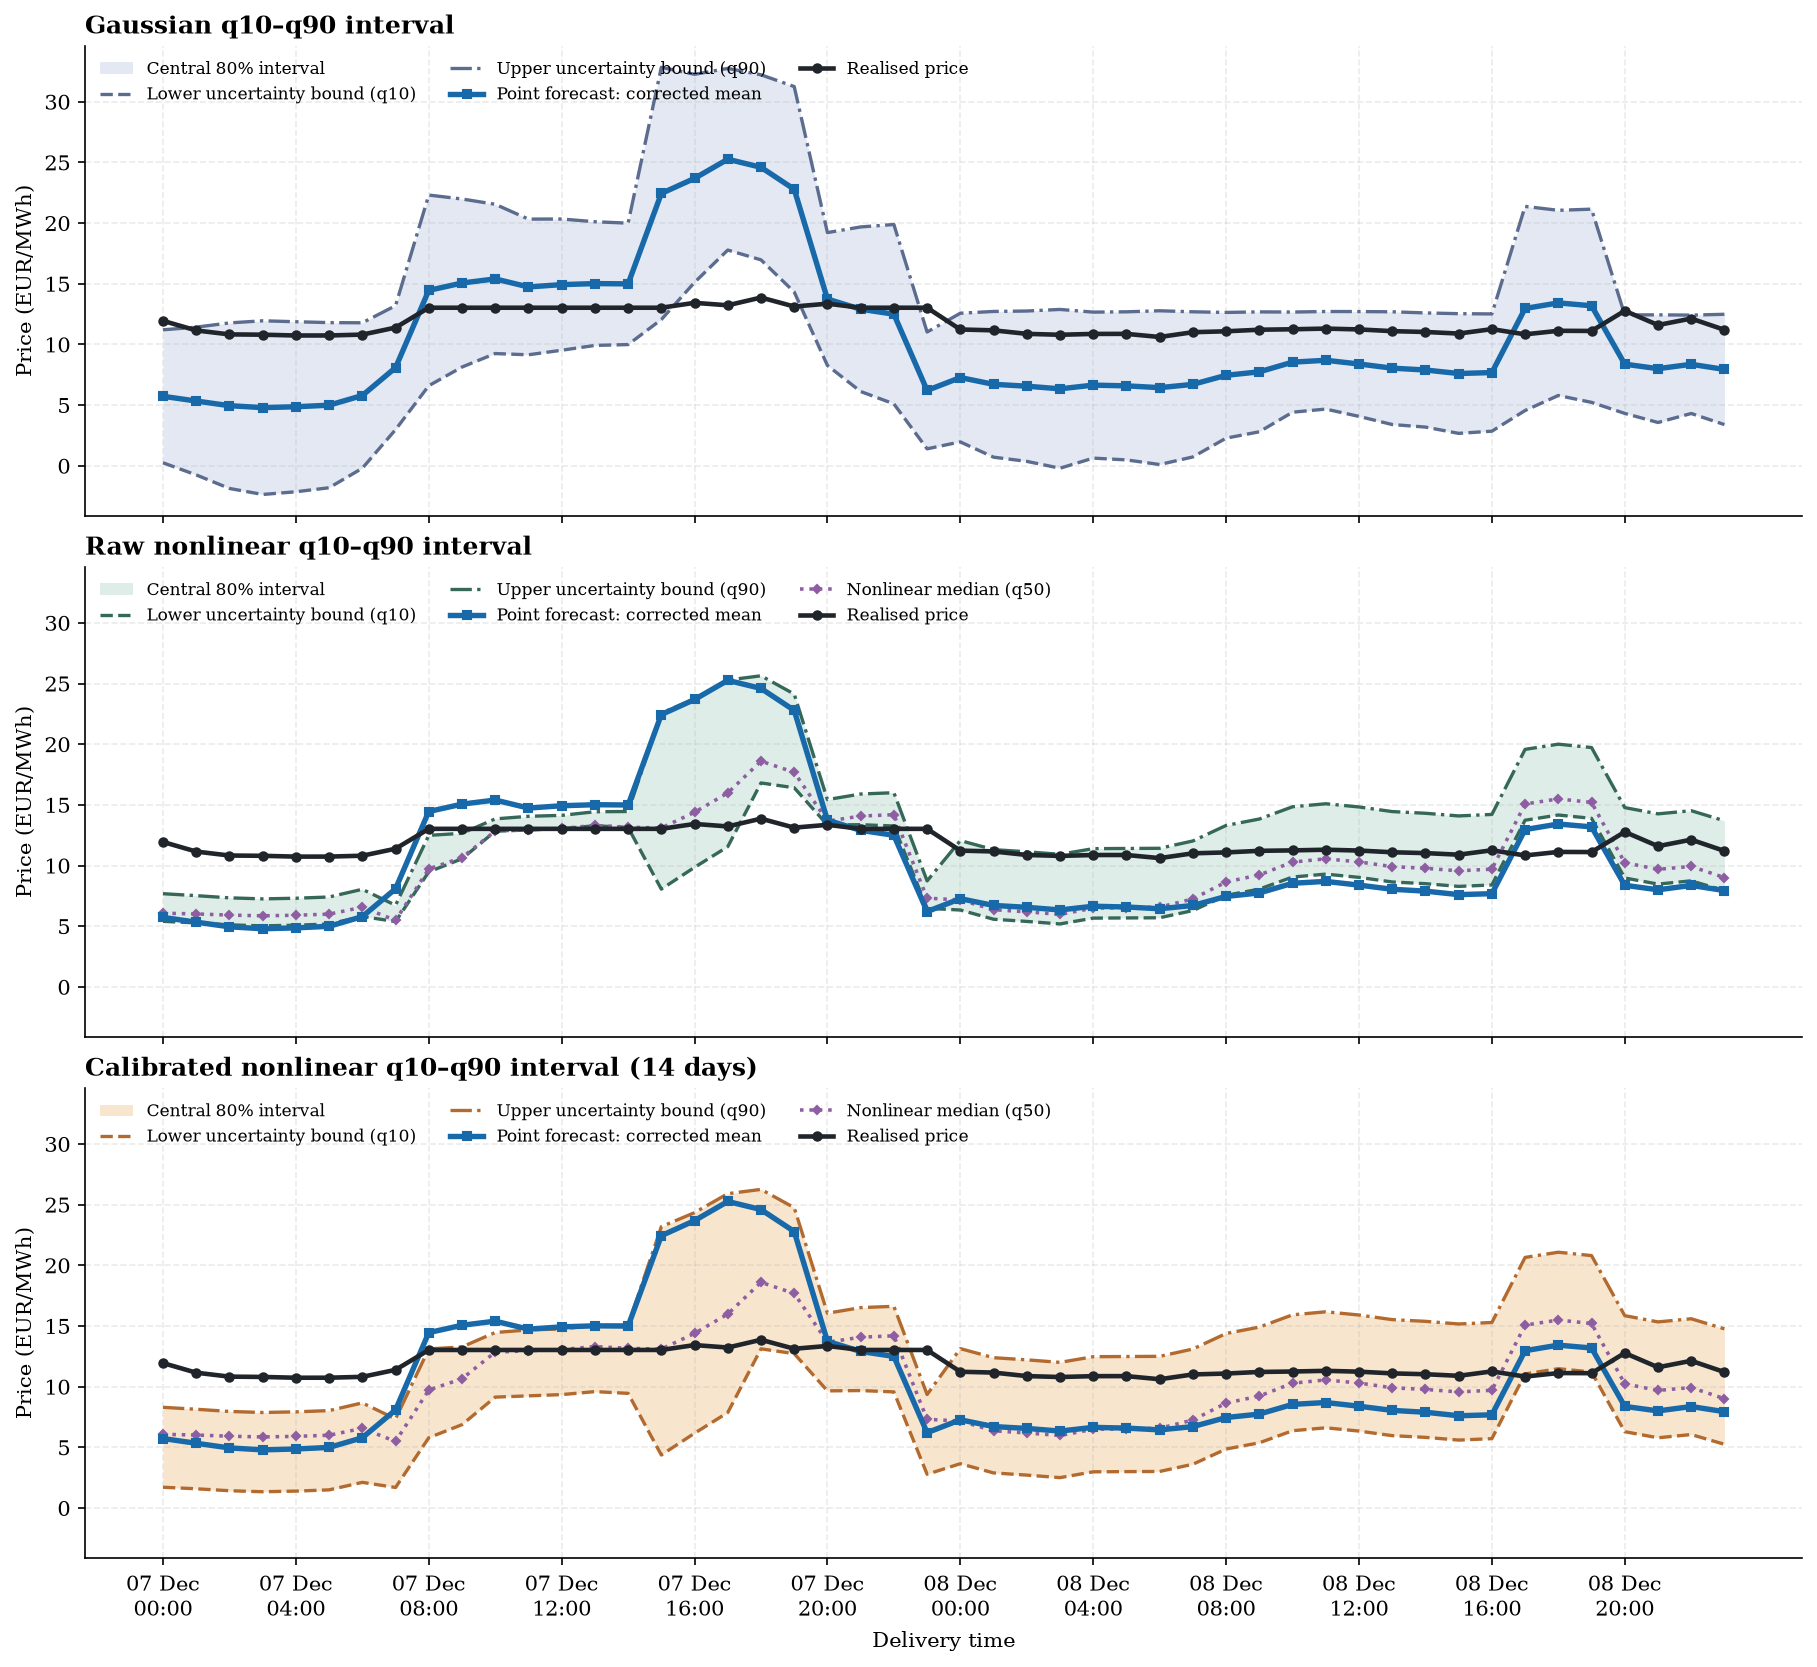

In [111]:
gaussian_48_hours = gaussian_uncertainty[
    gaussian_uncertainty.product_start.between(
        window_start, window_end, inclusive="left"
    )
].set_index("product_start")
nonlinear_48_hours = calibrated_nonlinear[
    calibrated_nonlinear.product_start.between(
        window_start, window_end, inclusive="left"
    )
].set_index("product_start")

delivery_time = nonlinear_48_hours.index
fig, axes = plt.subplots(
    3, 1, figsize=(12, 11), sharex=True, sharey=True, constrained_layout=True
)
panels = (
    (
        axes[0],
        gaussian_48_hours,
        "price_q10",
        "price_q90",
        "#DCE3EF",
        "#5B6C8F",
        "Gaussian q10–q90 interval",
        False,
    ),
    (
        axes[1],
        nonlinear_48_hours,
        "price_q10",
        "price_q90",
        "#D7E9E3",
        "#356859",
        "Raw nonlinear q10–q90 interval",
        True,
    ),
    (
        axes[2],
        nonlinear_48_hours,
        "calibrated_q10",
        "calibrated_q90",
        "#F7DFC2",
        "#B36A2E",
        f"Calibrated nonlinear q10–q90 interval ({selected_window})",
        True,
    ),
)

for axis, frame, lower, upper, fill, boundary, title, show_q50 in panels:
    axis.fill_between(
        delivery_time,
        frame[lower],
        frame[upper],
        color=fill,
        alpha=0.8,
        linewidth=0,
        label="Central 80% interval",
        zorder=1,
    )
    axis.plot(
        delivery_time,
        frame[lower],
        color=boundary,
        linewidth=1.6,
        linestyle="--",
        label="Lower uncertainty bound (q10)",
        zorder=2,
    )
    axis.plot(
        delivery_time,
        frame[upper],
        color=boundary,
        linewidth=1.6,
        linestyle="-.",
        label="Upper uncertainty bound (q90)",
        zorder=2,
    )
    axis.plot(
        delivery_time,
        frame.corrected_price_mean_forecast,
        color="#1769AA",
        linewidth=2.6,
        marker="s",
        markersize=4,
        label="Point forecast: corrected mean",
        zorder=5,
    )
    if show_q50:
        axis.plot(
            delivery_time,
            frame.price_q50,
            color="#8E5EA2",
            linewidth=1.7,
            linestyle=":",
            marker="D",
            markersize=3,
            label="Nonlinear median (q50)",
            zorder=4,
        )
    axis.plot(
        delivery_time,
        frame.realised_price,
        color="#20252B",
        linewidth=2.2,
        marker="o",
        markersize=4,
        label="Realised price",
        zorder=6,
    )
    axis.set_title(title, loc="left", fontweight="bold")
    axis.set_ylabel("Price (EUR/MWh)")
    axis.legend(frameon=False, ncol=3, fontsize=8, loc="upper left")

axes[2].set_xlabel("Delivery time")
axes[2].set_xticks(delivery_time[::4])
axes[2].set_xticklabels(delivery_time[::4].strftime("%d %b\n%H:%M"))
# fig.suptitle(
#     "48-hour comparison: common point forecast and uncertainty intervals",
#     fontsize=14,
#     fontweight="bold",
# )
plt.show()

In [112]:
def interval_score_rows(frame, lower_column, upper_column):
    actual = frame.realised_price
    lower = frame[lower_column]
    upper = frame[upper_column]
    return (
        upper
        - lower
        + 10 * (lower - actual) * (actual < lower)
        + 10 * (actual - upper) * (actual > upper)
    )


paired_scores = holdout_gaussian[
    ["issue_time", "product_start", "realised_price", "price_q10", "price_q90"]
].merge(
    holdout_calibrated[["product_start", "calibrated_q10", "calibrated_q90"]],
    on="product_start",
    validate="one_to_one",
)
paired_scores["gaussian_score"] = interval_score_rows(
    paired_scores, "price_q10", "price_q90"
)
paired_scores["nonlinear_score"] = interval_score_rows(
    paired_scores, "calibrated_q10", "calibrated_q90"
)
daily_scores = paired_scores.groupby("issue_time")[
    ["gaussian_score", "nonlinear_score"]
].mean()
daily_difference = (
    daily_scores.nonlinear_score - daily_scores.gaussian_score
).to_numpy()
generator = np.random.default_rng(20260903)
bootstrap_means = daily_difference[
    generator.integers(0, len(daily_difference), size=(20000, len(daily_difference)))
].mean(axis=1)
print(f"Mean interval-score difference: {daily_difference.mean():.3f}")
print(
    f"95% daily block-bootstrap interval: {np.quantile(bootstrap_means, [0.025, 0.975])}"
)
print(
    f"Bootstrap probability that calibrated nonlinear is better: {(bootstrap_means < 0).mean():.1%}"
)

Mean interval-score difference: -0.520
95% daily block-bootstrap interval: [-2.56041615  1.57924069]
Bootstrap probability that calibrated nonlinear is better: 69.1%


## 6. Point-error ranking with the nonlinear result

This reproduces the earlier ranking of the 66 LASSO feature combinations and adds **one** nonlinear-q50 comparator. That comparator uses the same six inputs as the selected corrected-mean model; it is not a separate 66-combination nonlinear feature screen. The selected LASSO model forecasts the conditional **mean** correction, while the nonlinear model forecasts the conditional **median** (q50). Conformal calibration is not shown separately because it changes q10/q90 only; q50, MAE, and RMSE are unchanged.

,development_MAE,development_RMSE,holdout_MAE,holdout_RMSE
forecast,,,,
Selected six-feature LASSO mean model,3.752,5.055,3.898,5.131
Nonlinear q50 on selected six inputs,3.401,4.711,3.779,5.233


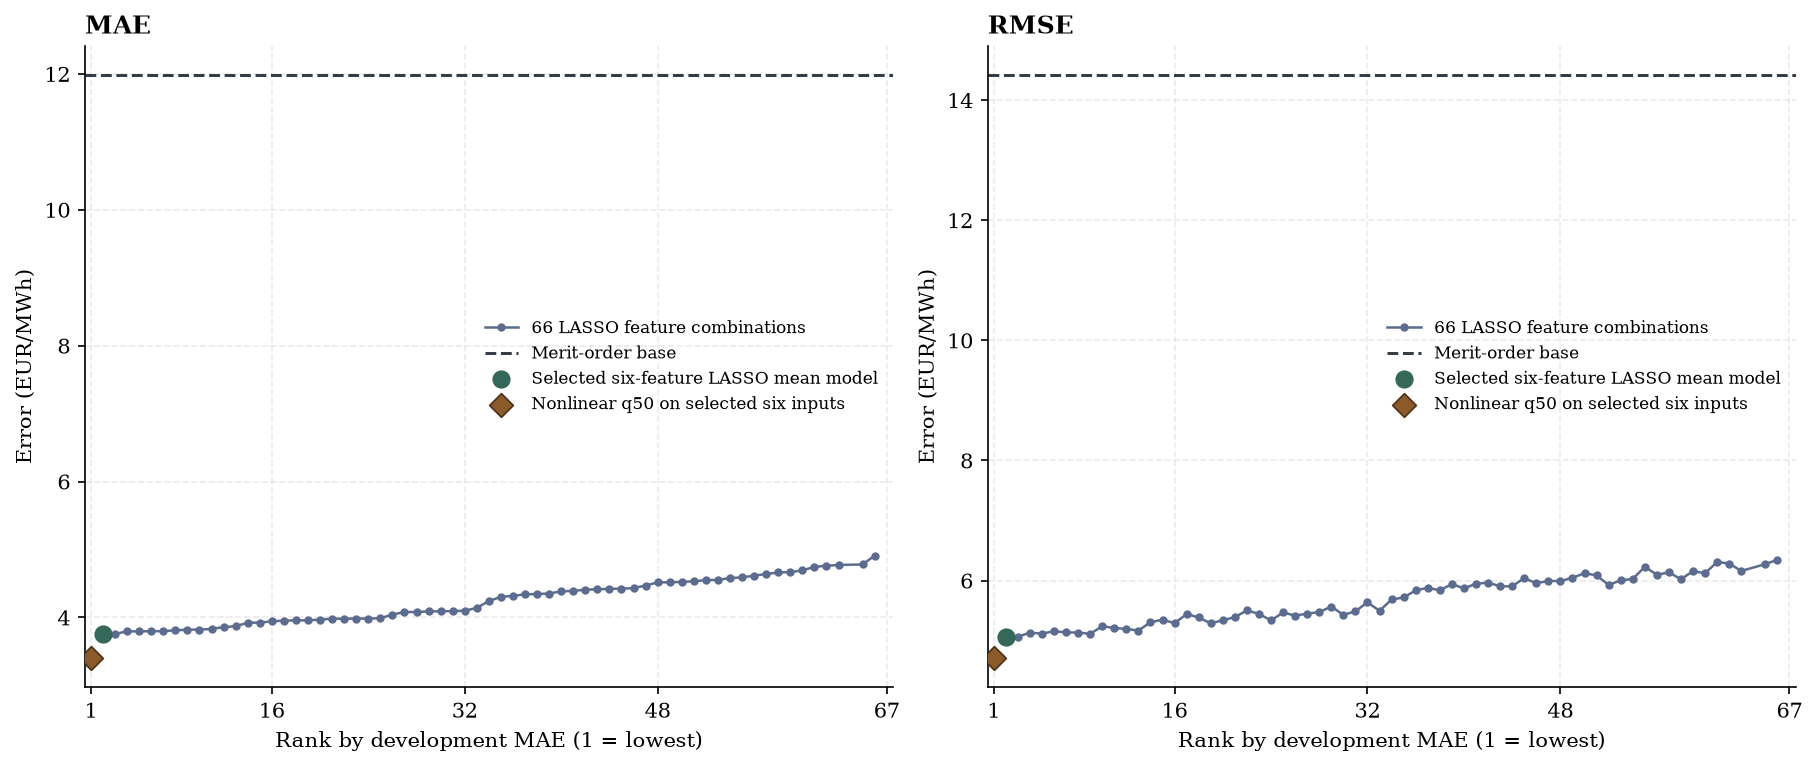

Selected corrected-mean LASSO combination (green circle):
Features: merit_order_price, wind_availability_factor, solar_availability_factor, residual_load, previous_day_same_hour_price, weekday
Development — MAE: 3.752 EUR/MWh; RMSE: 5.055 EUR/MWh
Holdout — MAE: 3.898 EUR/MWh; RMSE: 5.131 EUR/MWh


In [113]:
def point_error_metrics(frame, forecast_column):
    error = frame.realised_price - frame[forecast_column]
    return error.abs().mean(), (error**2).mean() ** 0.5


nonlinear_rows = {}
for period, part in {
    "development": nonlinear_uncertainty[
        nonlinear_uncertainty.product_start < "2019-10-01"
    ],
    "holdout": nonlinear_uncertainty[
        nonlinear_uncertainty.product_start >= "2019-10-01"
    ],
}.items():
    mae, rmse = point_error_metrics(part, "price_q50")
    nonlinear_rows[f"{period}_mae"] = mae
    nonlinear_rows[f"{period}_rmse"] = rmse
    nonlinear_rows[f"{period}_samples"] = len(part)

nonlinear_case = {
    "features": "nonlinear_quantile q50 (same six selected inputs)",
    "feature_count": 6,
    "case_type": "New nonlinear q50 median forecast",
} | nonlinear_rows
cases_with_nonlinear = (
    pd.concat([all_cases, pd.DataFrame([nonlinear_case])], ignore_index=True)
    .sort_values("development_mae")
    .reset_index(drop=True)
)
cases_with_nonlinear["rank"] = range(1, len(cases_with_nonlinear) + 1)
new_result = cases_with_nonlinear[
    cases_with_nonlinear.case_type.eq("New nonlinear q50 median forecast")
].iloc[0]
lasso_cases = cases_with_nonlinear[
    cases_with_nonlinear.case_type.eq("Feature-screen combination")
]

display(
    pd.DataFrame(
        [
            {
                "forecast": "Selected six-feature LASSO mean model",
                "development_MAE": all_cases.iloc[0].development_mae,
                "development_RMSE": all_cases.iloc[0].development_rmse,
                "holdout_MAE": all_cases.iloc[0].holdout_mae,
                "holdout_RMSE": all_cases.iloc[0].holdout_rmse,
            },
            {
                "forecast": "Nonlinear q50 on selected six inputs",
                "development_MAE": new_result.development_mae,
                "development_RMSE": new_result.development_rmse,
                "holdout_MAE": new_result.holdout_mae,
                "holdout_RMSE": new_result.holdout_rmse,
            },
        ]
    )
    .set_index("forecast")
    .round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, constrained_layout=True)
for axis, metric, title in zip(axes, ["mae", "rmse"], ["MAE", "RMSE"]):
    column = f"development_{metric}"
    axis.plot(
        lasso_cases["rank"],
        lasso_cases[column],
        color="#5B6C8F",
        linewidth=1.2,
        marker="o",
        markersize=3,
        label="66 LASSO feature combinations",
    )
    axis.axhline(
        merit_order.iloc[0][column],
        color="#303841",
        linestyle="--",
        linewidth=1.4,
        label="Merit-order base",
    )
    best_mean = lasso_cases.iloc[0]
    axis.scatter(
        best_mean["rank"],
        best_mean[column],
        color="#356859",
        s=60,
        zorder=4,
        label="Selected six-feature LASSO mean model",
    )
    axis.scatter(
        new_result["rank"],
        new_result[column],
        color="#8B5A2B",
        s=65,
        marker="D",
        edgecolor="#4D3017",
        linewidth=0.8,
        zorder=5,
        label="Nonlinear q50 on selected six inputs",
    )
    axis.set_title(title, loc="left", fontweight="bold")
    axis.set_xlabel("Rank by development MAE (1 = lowest)")
    axis.set_ylabel("Error (EUR/MWh)")
    axis.set_xlim(0.5, len(cases_with_nonlinear) + 0.5)
    axis.legend(frameon=False, fontsize=8)
axes[0].set_xticks([1, 16, 32, 48, 67])
axes[1].set_xticks([1, 16, 32, 48, 67])
# fig.suptitle(
#     "Development point-error comparison: 66 existing cases plus nonlinear q50",
#     fontsize=13,
#     fontweight="bold",
# )
plt.show()

print(
    "Selected corrected-mean LASSO combination (green circle):\n"
    f"Features: {best_mean['features']}\n"
    f"Development — MAE: {best_mean.development_mae:.3f} EUR/MWh; "
    f"RMSE: {best_mean.development_rmse:.3f} EUR/MWh\n"
    f"Holdout — MAE: {best_mean.holdout_mae:.3f} EUR/MWh; "
    f"RMSE: {best_mean.holdout_rmse:.3f} EUR/MWh"
)

### Interpretation

The raw nonlinear-quantile model should not replace Gaussian: its holdout interval is about 32% narrower but covers only 57.83% of outcomes. Separate-tail conformal calibration is therefore required. A 14-day calibration window, selected exclusively on development data, reaches 79.12% holdout coverage with 11.49% below q10 and 9.39% above q90. Its mean width is 11.44 EUR/MWh, only about 1.3% wider than Gaussian, while its interval score improves from 17.80 to 17.28.

The paired daily bootstrap interval includes zero, so the interval-score improvement is promising rather than statistically conclusive from one simulated year. Gaussian should remain the default until calibrated nonlinear quantiles are evaluated across additional years or scenarios.